<a href="https://colab.research.google.com/github/avikumart/DA-DS-Questions/blob/main/Forage_DS_Sim/Task_2_eda_starter_and_Task_3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis Starter

## Import packages

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

In [1]:
# connect the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---

## Loading data with Pandas

We need to load `client_data.csv` and `price_data.csv` into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the `read_csv` method accordingly.

In [4]:
client_df = pd.read_csv('/content/drive/MyDrive/DS job sim - Forage/client_data (1).csv')
price_df = pd.read_csv('/content/drive/MyDrive/DS job sim - Forage/price_data (1).csv')

You can view the first 3 rows of a dataframe using the `head` method. Similarly, if you wanted to see the last 3, you can use `tail(3)`

In [5]:
client_df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.0,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.0,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.0,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0


In [6]:
price_df.head(3)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0


---

## Descriptive statistics of data

### Data types

It is useful to first understand the data that you're dealing with along with the data types of each column. The data types may dictate how you transform and engineer features.

To get an overview of the data types within a data frame, use the `info()` method.

In [7]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [8]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


### Statistics

Now let's look at some statistics about the datasets. We can do this by using the `describe()` method.

In [9]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [10]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


---

## Data visualization

If you're working in Python, two of the most popular packages for visualization are `matplotlib` and `seaborn`. We highly recommend you use these, or at least be familiar with them because they are ubiquitous!

Below are some functions that you can use to get started with visualizations.

In [11]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:

        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

Thhe first function `plot_stacked_bars` is used to plot a stacked bar chart. An example of how you could use this is shown below:

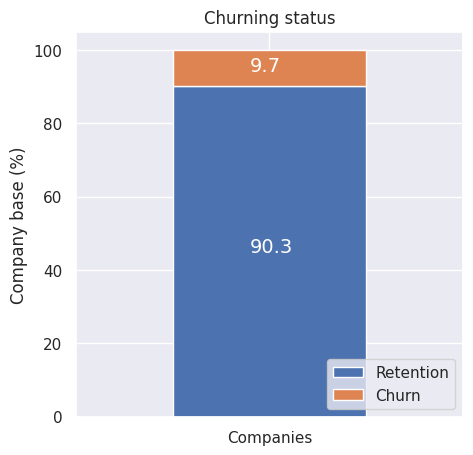

In [12]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

The second function `annotate_bars` is used by the first function, but the third function `plot_distribution` helps you to plot the distribution of a numeric column. An example of how it can be used is given below:

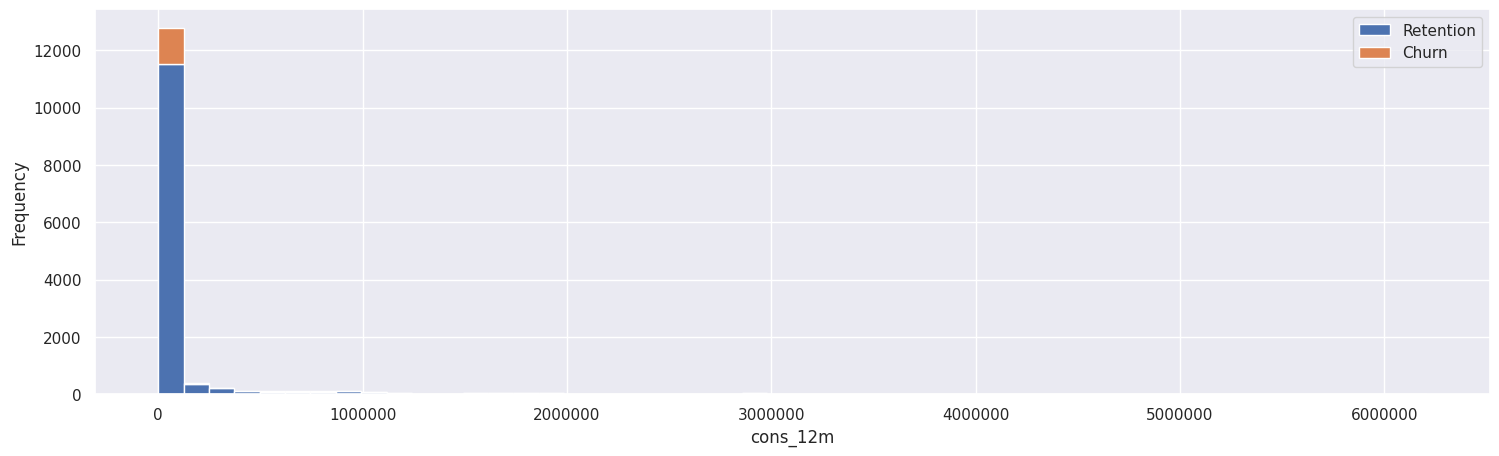

In [13]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

fig, axs = plt.subplots(nrows=1, figsize=(18, 5))

plot_distribution(consumption, 'cons_12m', axs)

In [14]:
# calculat the ratio of churn vs price increase
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [83]:
# groupby customer to calculate the average price paid
pm_df = price_df.groupby("id").agg("price_off_peak_fix").mean()

In [84]:
# merge the pm_df to client_df on the id column
df = client_df.merge(pm_df, on="id")
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn,price_off_peak_fix
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,40.942265
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,44.311375
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,44.385450
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,44.400265
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,40.688156


In [85]:
df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn,price_off_peak_fix
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152,42.928890
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175,4.550759
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000,40.688156
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000,44.281745
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000,44.370635
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000,59.286190


In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 27 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

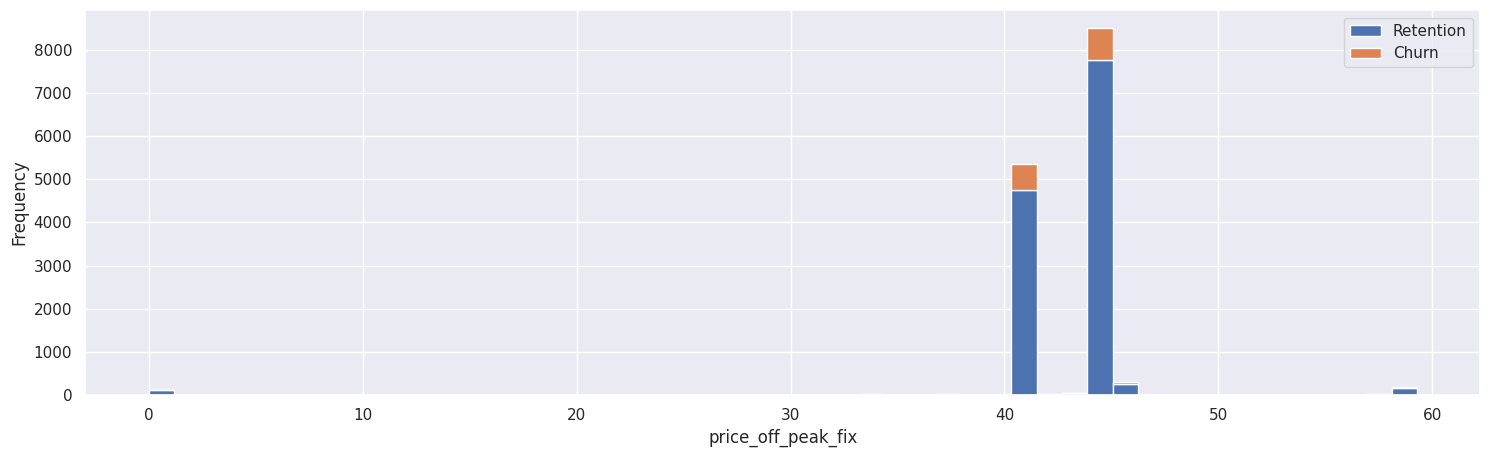

In [19]:
# create the chart of the the distribuion of price and churn effects
fig, axs = plt.subplots(nrows=1, figsize=(18, 5))

plot_distribution(df, 'price_off_peak_fix', axs)

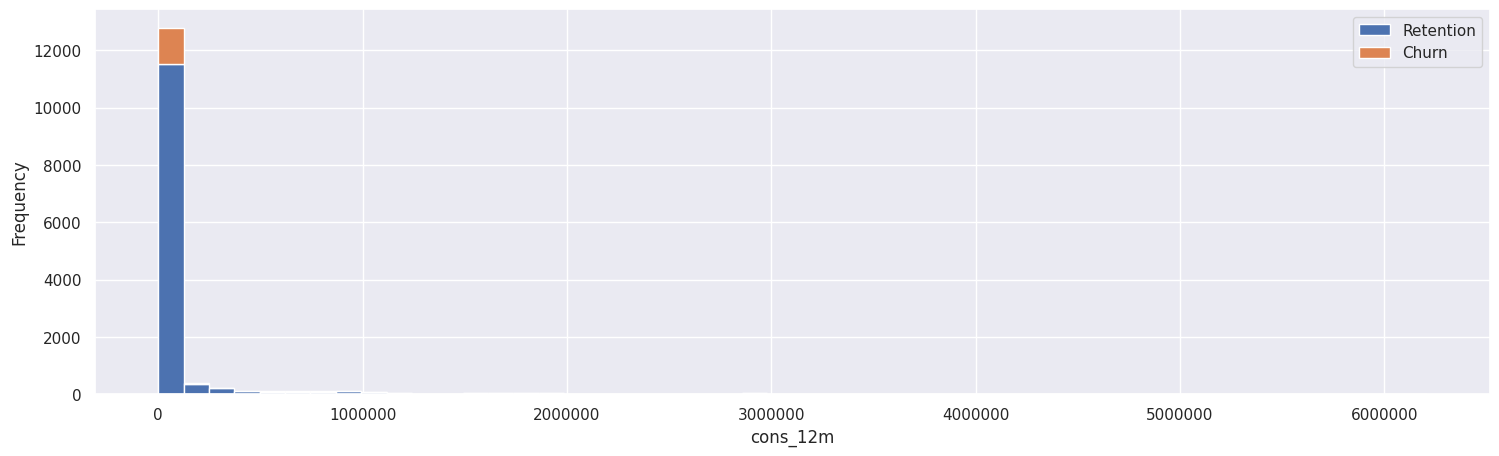

In [20]:
# chart of cons_12m
fig, axs = plt.subplots(nrows=1, figsize=(18, 5))

plot_distribution(df, 'cons_12m', axs)

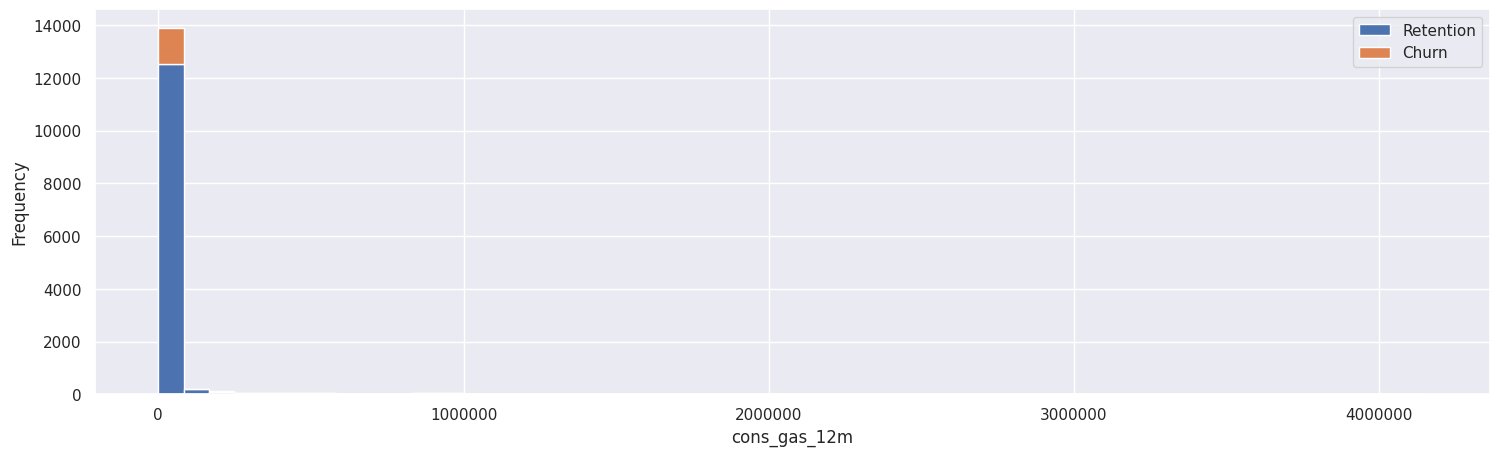

In [21]:
# plot for gas consumption column
fig, axs = plt.subplots(nrows=1, figsize=(18, 5))

plot_distribution(df, 'cons_gas_12m', axs)

In [22]:
# pivot table to find average consumption by churn
df.pivot_table(index='churn', values=['cons_12m', 'cons_gas_12m'])

,cons_12m,cons_gas_12m
churn,,
0,167867.266550,30121.497308
1,78862.478506,9235.411557


In [23]:
# pivot table to find the peak price by churn\
df.pivot_table(index='churn', values=['price_off_peak_fix'])

,price_off_peak_fix
churn,
0,42.903812
1,43.161941


In [24]:
# pivot table to find consumption demand by churn
ratio_df = df.pivot_table(index='churn', values=['imp_cons',"cons_12m","cons_gas_12m","price_off_peak_fix"])
ratio_df

,cons_12m,cons_gas_12m,imp_cons,price_off_peak_fix
churn,,,,
0,167867.266550,30121.497308,152.964184,42.903812
1,78862.478506,9235.411557,151.139331,43.161941


In [25]:
# find the price elasticity factor based on change in demand vs price change
cons_el = ((ratio_df["cons_12m"][1] - ratio_df["cons_12m"][0])/ratio_df["cons_12m"][0])*100 / ((ratio_df["price_off_peak_fix"][1] - ratio_df["price_off_peak_fix"][0])/ratio_df["price_off_peak_fix"][0])*100
print(f"The price elasticity factor is {cons_el}")

The price elasticity factor is -881264.2716379687


In [26]:
# find the churn relations with sales channels
sales_df = df.pivot_table(index='churn', columns='channel_sales', values='cons_12m', aggfunc='sum')
sales_df

channel_sales,MISSING,epumfxlbckeskwekxbiuasklxalciiuu,ewpakwlliwisiwduibdlfmalxowmwpci,fixdbufsefwooaasfcxdxadsiekoceaa,foosdfpfkusacimwkcsosbicdxkicaua,lmkebamcaaclubfxadlmueccxoimlema,sddiedcslfslkckwlfkdpoeeailfpeds,usilxuppasemubllopkaafesmlibmsdf
churn,,,,,,,,
0,403914044.0,69238.0,32411875.0,2509030.0,606500336.0,1.144103e+09,191497.0,23966399.0
1,19549225.0,NaN,1818462.0,NaN,55038915.0,3.247859e+07,NaN,3020669.0


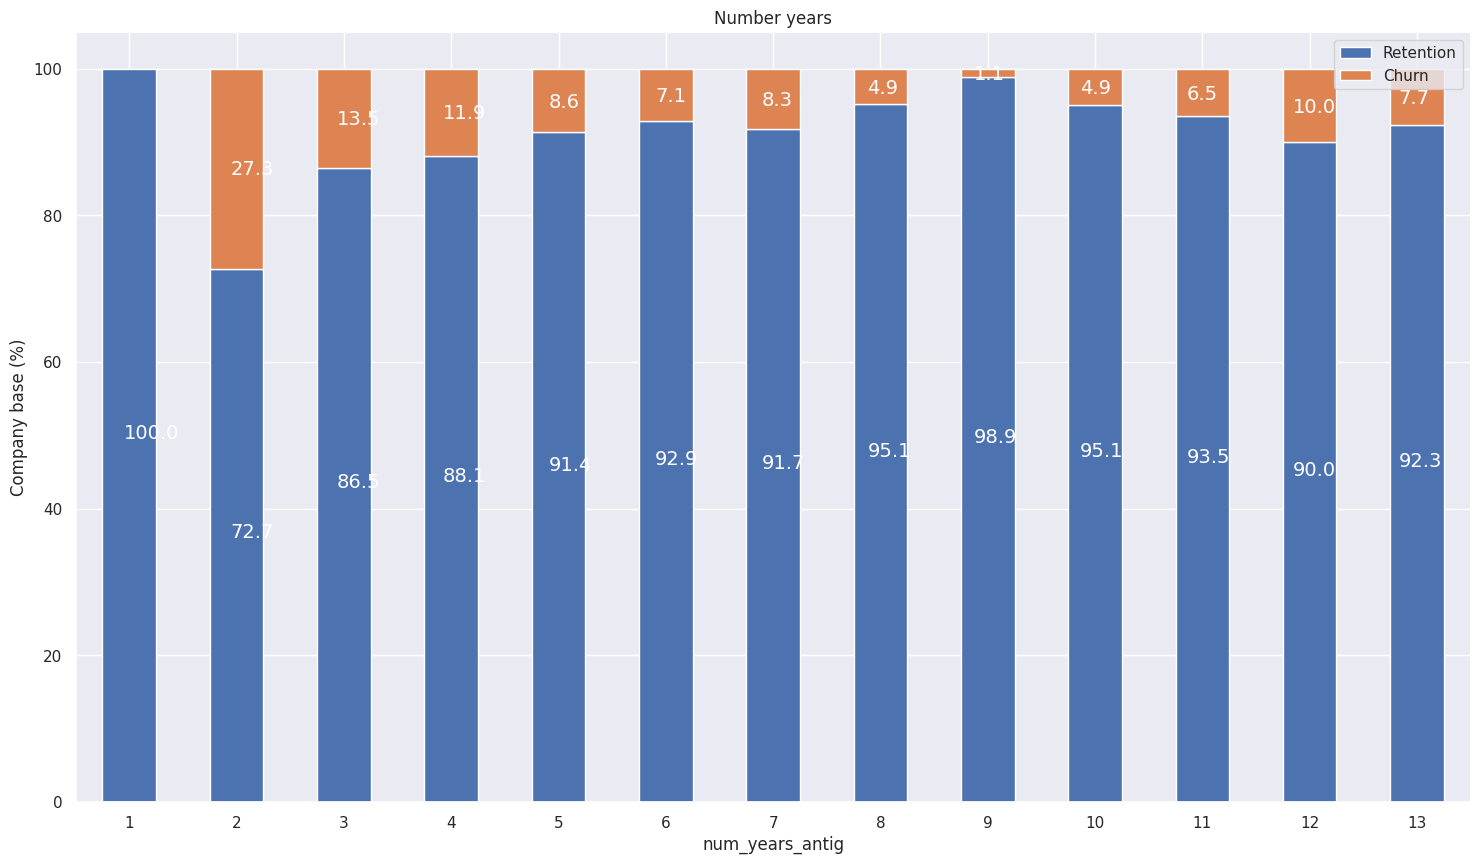

In [28]:
others = client_df[['id', 'nb_prod_act', 'num_years_antig', 'origin_up', 'churn']]

years_antig = others.groupby([others["num_years_antig"],others["churn"]])["id"].count().unstack(level=1)
years_antig_percentage = (years_antig.div(years_antig.sum(axis=1), axis=0)*100)
plot_stacked_bars(years_antig_percentage, "Number years")

In [30]:
# code to analyze the origin up for the churn analysis
origin_up = others.groupby([others["origin_up"],others["churn"]])["id"].count().unstack(level=1)
origin_up

churn,0,1
origin_up,,
MISSING,60.0,4.0
ewxeelcelemmiwuafmddpobolfuxioce,1.0,NaN
kamkkxfxxuwbdslkwifmmcsiusiuosws,4036.0,258.0
ldkssxwpmemidmecebumciepifcamkci,2884.0,264.0
lxidpiddsbxsbosboudacockeimpuepw,6204.0,893.0
usapbepcfoloekilkwsdiboslwaxobdp,2.0,NaN


### Analysis of the power_max feature

In [33]:
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn,price_off_peak_fix
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,40.942265
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,44.311375
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,44.385450
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,44.400265
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,40.688156


In [32]:
# define the a function to plot the distribuion function between input variable and churn variable
def dist(df,col):
  fig, axs = plt.subplots(nrows=1, figsize=(18, 5))
  plot_distribution(df, col, axs)

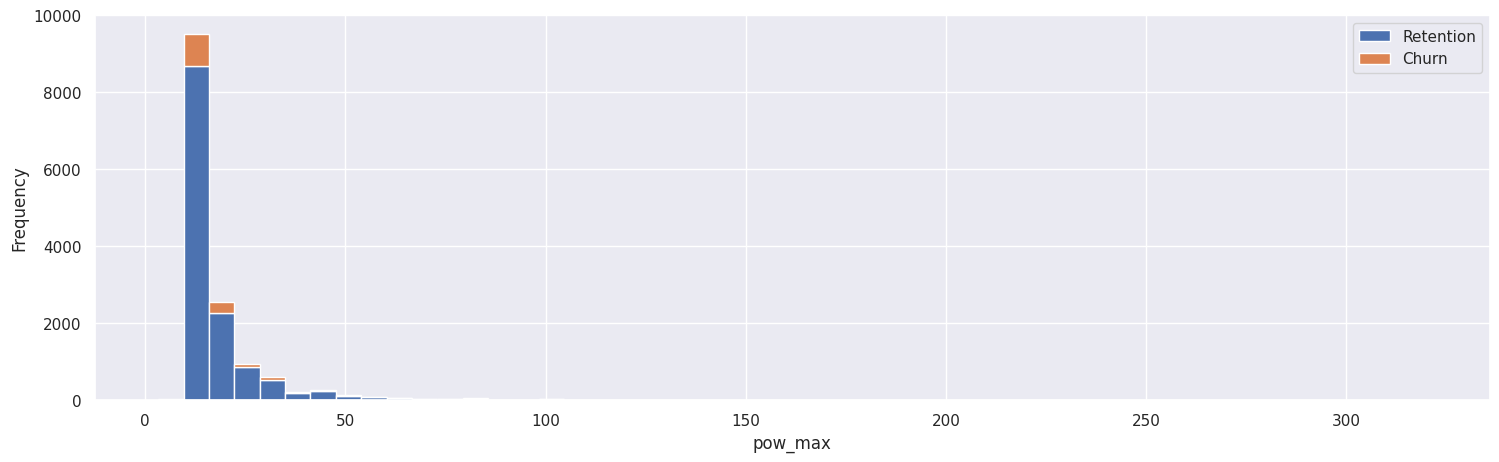

In [35]:
dist(df,'pow_max')

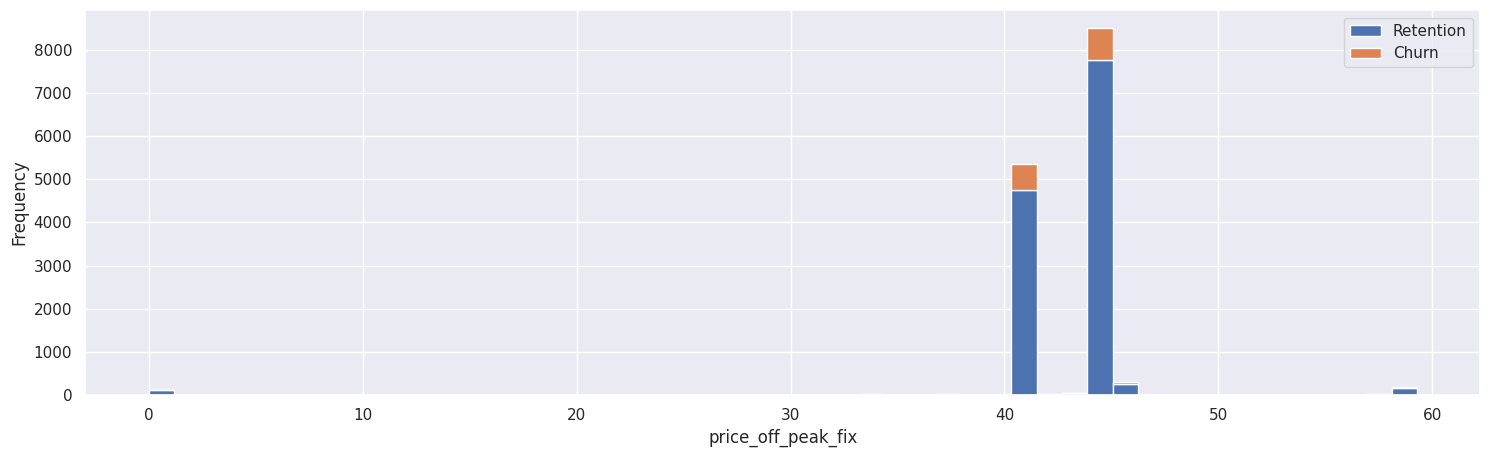

In [36]:
# chart of the price_off_peak_fix
dist(df,'price_off_peak_fix')

## Insights:

1. Prices are highly effective in the the demand of the consumtion
2. Churned customers are sensitive of incrase in price since their consumtion has reduced while price increased with elasticity of the above 1
3. lower number of years lead to higher churn
4. some origin of the subscription lead to high churn than others
5. Different sales channels have varying churn rates.

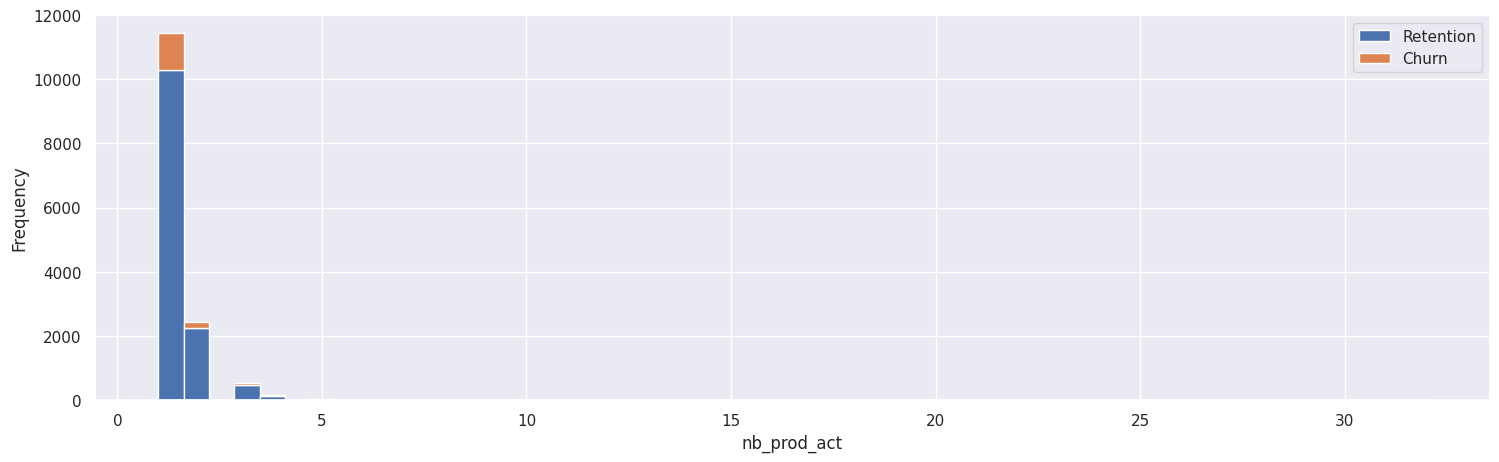

In [37]:
# chart of nb_prod_act
dist(df,'nb_prod_act')

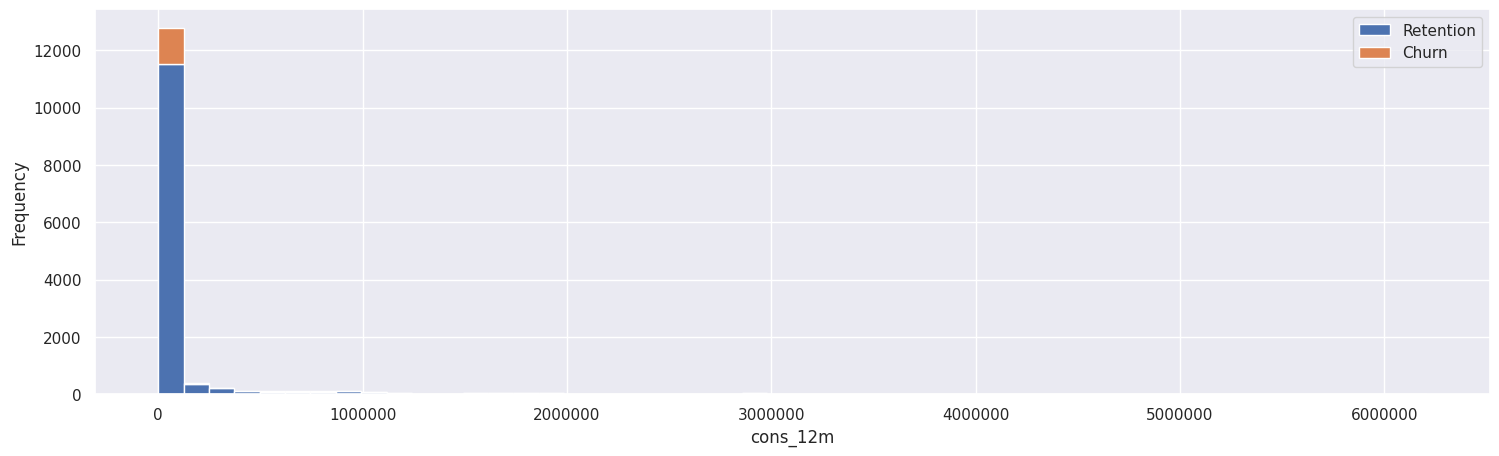

In [38]:
# chart of cons_12m
dist(df,'cons_12m')

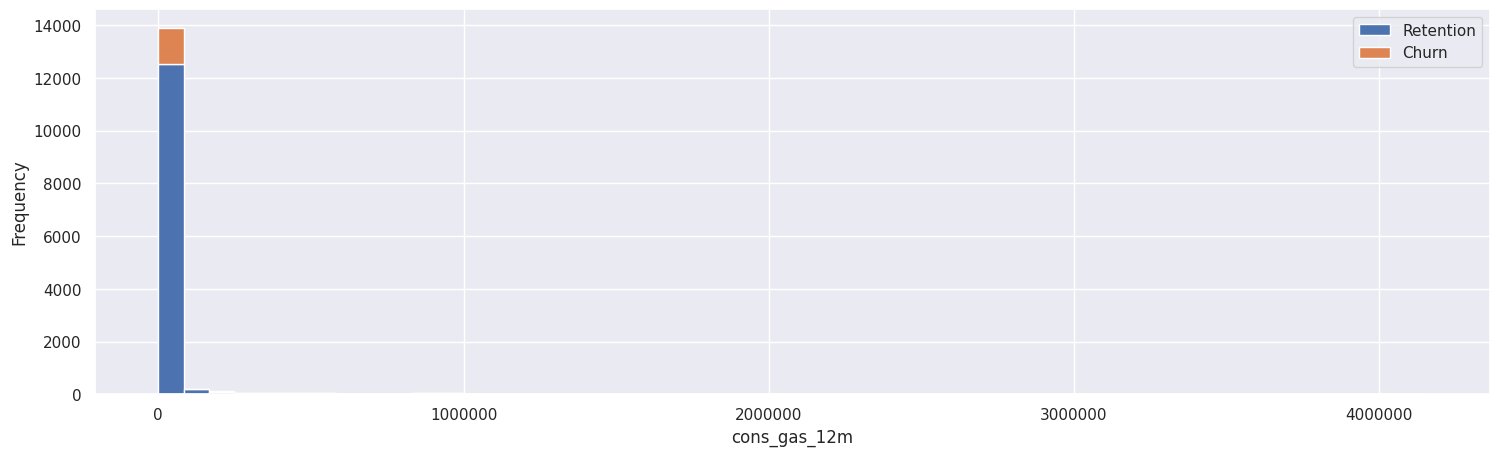

In [42]:
# chart of cons_gas_12m
dist(df,'cons_gas_12m')

## Insights:

1. Lower enery usage consumers are more likely to churn, so you want to give them a discount to increase the usage
2. lower the number of active products, the more they are likely to churn

##  Task - 3 Feature extraction and engineering

In [87]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [74]:
gprice_df = price_df.groupby(["id","price_date"]).agg({"price_off_peak_fix":'mean',"price_mid_peak_fix":'mean'})


gprice_df_jan = gprice_df.groupby("id").first().reset_index()
gprice_df_dec = gprice_df.groupby("id").last().reset_index()

gprice_df_comb = gprice_df_jan.merge(gprice_df_dec, on="id")
gprice_df_comb.head()

# add the diff column to the gprice average price
gprice_df = gprice_df.groupby("id").agg({"price_off_peak_fix":'mean',"price_mid_peak_fix":'mean'})
gprice_df = gprice_df.merge(gprice_df_comb, on="id")
gprice_df["off_peak_diff"] = gprice_df["price_off_peak_fix_y"] - gprice_df["price_off_peak_fix_x"]
gprice_df["mid_peak_diff"] = gprice_df["price_mid_peak_fix_y"] - gprice_df["price_mid_peak_fix_x"]
gprice_df = gprice_df.drop(columns=["price_off_peak_fix_x","price_off_peak_fix_y","price_mid_peak_fix_x","price_mid_peak_fix_y"])
gprice_df = gprice_df.drop(columns=["price_off_peak_fix"])
gprice_df.head()

,id,price_mid_peak_fix,off_peak_diff,mid_peak_diff
0,0002203ffbb812588b632b9e628cc38d,16.280694,0.162916,0.065166
1,0004351ebdd665e6ee664792efc4fd13,0.000000,0.177779,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.000000,1.500000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,16.258971,0.162916,0.065166
4,00114d74e963e47177db89bc70108537,0.000000,-0.000001,0.000000


In [88]:
# merge with df final combined dataset
df = df.merge(gprice_df, on="id")

In [89]:
# create new feature averaging total energy consumption by ids
df["total_cons"] = (df["cons_12m"] + df["cons_gas_12m"] + df["cons_last_month"]) / 3
df = df.drop(columns=["cons_12m","cons_gas_12m","cons_last_month"])
df.head()

,id,channel_sales,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,...,net_margin,num_years_antig,origin_up,pow_max,churn,price_off_peak_fix,price_mid_peak_fix,off_peak_diff,mid_peak_diff,total_cons
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,...,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,40.942265,14.901340,3.700961,-16.226389,18315.333333
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,...,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,44.311375,0.000000,0.177779,0.000000,1553.333333
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,...,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,44.385450,0.000000,0.177779,0.000000,181.333333
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0.0,19.83,...,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,44.400265,0.000000,0.177779,0.000000,528.000000
4,149d57cf92fc41cf94415803a877cb4b,MISSING,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0.0,131.73,...,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,40.688156,16.275263,0.162916,0.065166,1650.333333


In [91]:
# drop the non important columns
df = df.drop(columns=["date_activ","date_end","date_modif_prod","date_renewal"])

In [93]:
# take average of the forecast energy consumtoion
df["forecast_cons"] = (df["forecast_cons_12m"] + df["forecast_cons_year"]) / 2
df = df.drop(columns=["forecast_cons_12m","forecast_cons_year"])

In [94]:
df.head()

,id,channel_sales,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,...,num_years_antig,origin_up,pow_max,churn,price_off_peak_fix,price_mid_peak_fix,off_peak_diff,mid_peak_diff,total_cons,forecast_cons
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,...,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,40.942265,14.901340,3.700961,-16.226389,18315.333333,0.000
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,...,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,44.311375,0.000000,0.177779,0.000000,1553.333333,94.975
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,...,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,44.385450,0.000000,0.177779,0.000000,181.333333,23.980
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,...,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,44.400265,0.000000,0.177779,0.000000,528.000000,120.020
4,149d57cf92fc41cf94415803a877cb4b,MISSING,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,...,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,40.688156,16.275263,0.162916,0.065166,1650.333333,485.875


In [95]:
# new feature of gross power sub - net power sub
df["gross_power"] = df["margin_gross_pow_ele"] - df["margin_net_pow_ele"]
df = df.drop(columns=["margin_gross_pow_ele","margin_net_pow_ele"])

In [96]:
df.head()

,id,channel_sales,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,nb_prod_act,...,origin_up,pow_max,churn,price_off_peak_fix,price_mid_peak_fix,off_peak_diff,mid_peak_diff,total_cons,forecast_cons,gross_power
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,2,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,40.942265,14.901340,3.700961,-16.226389,18315.333333,0.000,0.0
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,1,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,44.311375,0.000000,0.177779,0.000000,1553.333333,94.975,0.0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,1,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,44.385450,0.000000,0.177779,0.000000,181.333333,23.980,0.0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,1,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,44.400265,0.000000,0.177779,0.000000,528.000000,120.020,0.0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,1,...,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,40.688156,16.275263,0.162916,0.065166,1650.333333,485.875,0.0


In [97]:
# take average of the forescastd price of the ennery and create new feature
df["forecast_avg_price"] = (df["forecast_price_energy_off_peak"] + df["forecast_price_energy_peak"]) / 2
df = df.drop(columns=["forecast_price_energy_off_peak","forecast_price_energy_peak","forecast_price_pow_off_peak"])

In [98]:
df.head()

,id,channel_sales,forecast_discount_energy,forecast_meter_rent_12m,has_gas,imp_cons,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn,price_off_peak_fix,price_mid_peak_fix,off_peak_diff,mid_peak_diff,total_cons,forecast_cons,gross_power,forecast_avg_price
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0.0,1.78,t,0.00,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,40.942265,14.901340,3.700961,-16.226389,18315.333333,0.000,0.0,0.106312
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,0.0,16.27,f,0.00,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,44.311375,0.000000,0.177779,0.000000,1553.333333,94.975,0.0,0.072855
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,0.0,38.72,f,0.00,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,44.385450,0.000000,0.177779,0.000000,181.333333,23.980,0.0,0.126847
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,0.0,19.83,f,0.00,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,44.400265,0.000000,0.177779,0.000000,528.000000,120.020,0.0,0.073347
4,149d57cf92fc41cf94415803a877cb4b,MISSING,0.0,131.73,f,52.32,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,40.688156,16.275263,0.162916,0.065166,1650.333333,485.875,0.0,0.108457


In [99]:
# remove the channel_sales feature
df = df.drop(columns=["channel_sales"])
df.head()

,id,forecast_discount_energy,forecast_meter_rent_12m,has_gas,imp_cons,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn,price_off_peak_fix,price_mid_peak_fix,off_peak_diff,mid_peak_diff,total_cons,forecast_cons,gross_power,forecast_avg_price
0,24011ae4ebbe3035111d65fa7c15bc57,0.0,1.78,t,0.00,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,40.942265,14.901340,3.700961,-16.226389,18315.333333,0.000,0.0,0.106312
1,d29c2c54acc38ff3c0614d0a653813dd,0.0,16.27,f,0.00,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0,44.311375,0.000000,0.177779,0.000000,1553.333333,94.975,0.0,0.072855
2,764c75f661154dac3a6c254cd082ea7d,0.0,38.72,f,0.00,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0,44.385450,0.000000,0.177779,0.000000,181.333333,23.980,0.0,0.126847
3,bba03439a292a1e166f80264c16191cb,0.0,19.83,f,0.00,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0,44.400265,0.000000,0.177779,0.000000,528.000000,120.020,0.0,0.073347
4,149d57cf92fc41cf94415803a877cb4b,0.0,131.73,f,52.32,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0,40.688156,16.275263,0.162916,0.065166,1650.333333,485.875,0.0,0.108457


In [101]:
# save final df to csv to drive folder
df.to_csv('/content/drive/MyDrive/DS job sim - Forage/final_df.csv')